In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd

In [2]:
torch.manual_seed(42)

## Moving to GPU

1. Check device
  `device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')`

2. Move the Model to GPU
  `model = model.to(device)`

3. Modify training loop by moving data to GPU
  `batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)`

4. Modify evaluation loop by moving data to GPU
  `test_features, test_labels = test_features.to(device), test_labels(device)`

5. Optimize GPU Usage
  a. Increase batch_size
  b. Enable DataLoader pinning
  `pin_memory=True`

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [ ]:
df = pd.read_csv('/content/fashion-mnist_train.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'fashion-mnist_train.csv'

In [ ]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.shape

(60000, 785)

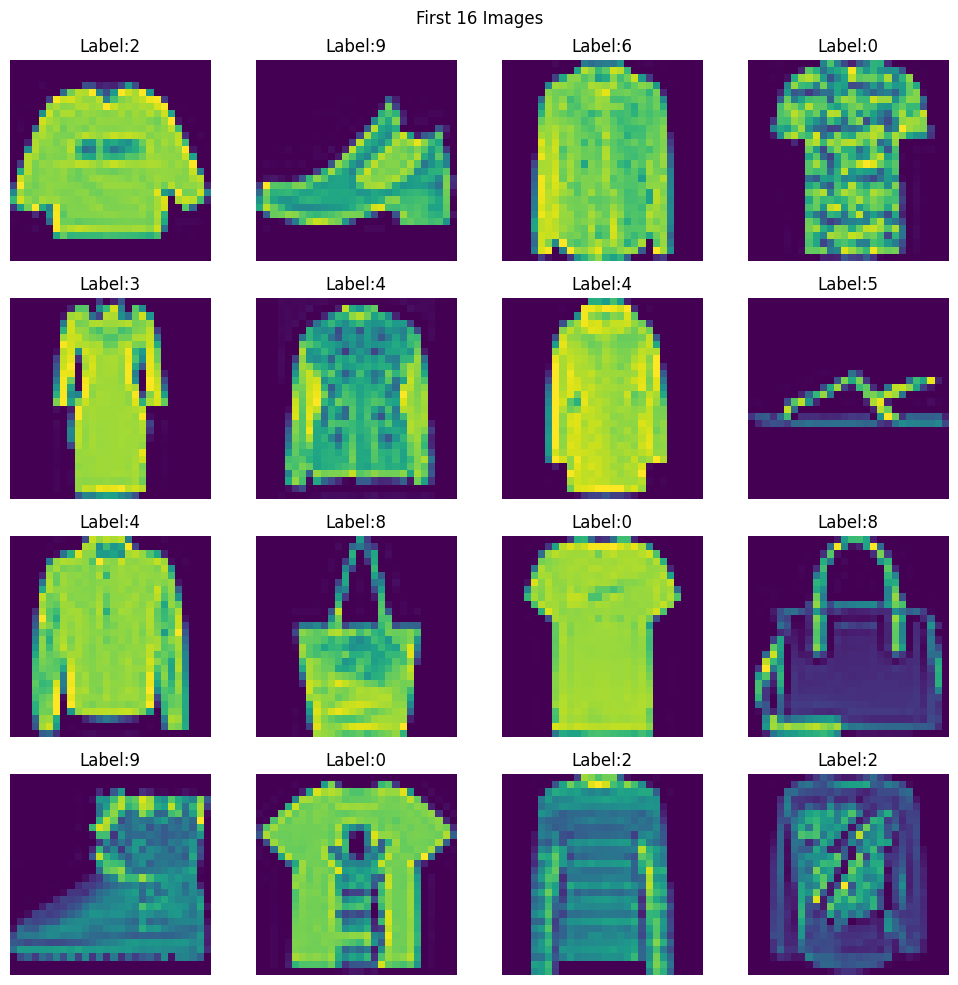

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(10,10))
fig.suptitle('First 16 Images')

for i, ax in enumerate(axes.flat):
  img = df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f'Label:{df.iloc[i,0]}')

plt.tight_layout()
plt.show()

In [ ]:
X = df.iloc[:, 1:].values
y = df.iloc[:,0].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train = X_train/255.0
X_test = X_test/255.0

In [ ]:
class CustomDataset(Dataset):

  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [ ]:
train_dataset = CustomDataset(X_train, y_train)

In [ ]:
test_dataset = CustomDataset(X_test, y_test)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, pin_memory=True)

In [ ]:
class myNN(nn.Module):

  def __init__(self, num_of_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_of_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )

  def forward(self, x):
    return self.model(x)

In [ ]:
epochs = 100
learning_rate = 0.01

In [ ]:
model = myNN(X_train.shape[1])
model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [ ]:
for epoch in range(epochs):
  total_loss = 0
  for batch_features, batch_labels in train_loader:

    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    predictions = model(batch_features)

    loss = criterion(predictions, batch_labels)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()
    total_loss += loss.item()

  avg_loss = total_loss/len(train_loader)
  if (epoch+1)%10==0:
      print(f"Epoch: [{epoch+1}] | Loss: [{avg_loss:.2f}]")

Epoch: [10] | Loss: [0.11]
Epoch: [20] | Loss: [0.10]
Epoch: [30] | Loss: [0.09]
Epoch: [40] | Loss: [0.08]
Epoch: [50] | Loss: [0.07]
Epoch: [60] | Loss: [0.06]
Epoch: [70] | Loss: [0.06]
Epoch: [80] | Loss: [0.05]
Epoch: [90] | Loss: [0.04]
Epoch: [100] | Loss: [0.04]


In [ ]:
model.eval()

myNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
total = 0
correct = 0

with torch.inference_mode():

  for test_features, test_labels in test_loader:

    test_features, test_labels = test_features.to(device), test_labels.to(device)
    outputs = model(test_features)

    _,prediction = torch.max(outputs, 1)

    total += test_labels.shape[0]
    correct += (prediction == test_labels).sum().item()

print(correct/total*100)

88.59166666666667


In [ ]:
total = 0
correct = 0

with torch.inference_mode():

  for batch_features, batch_labels in train_loader:

    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    outputs = model(batch_features)

    _,prediction = torch.max(outputs, 1)

    total += batch_labels.shape[0]
    correct += (prediction == batch_labels).sum().item()

print(correct/total*100)

99.16041666666666


## Model is overfitting
To reduce overfitting we can:
- add more data
- reduce complexity of NN architecture
- Regualrization
- Dropouts
- Data Augmentation
- Batch Normalization
- Early stopping